# Which Content Pages Should a Reviewer Refresh First?

## Abstract

This paper asks whether a content reviewer can use observed March signals to prioritize a short list of pages for refresh review before an observed April impression decline. It evaluates a transparent staleness-plus-volume baseline and a Logistic Regression model on warehouse-backed, leakage-controlled features and a grouped client holdout. The model did not clearly beat the baseline: its grouped-test ROC-AUC was below random, while the baseline remained more useful only at the very top of the full queue. The resulting playbook uses the transparent baseline as a human-review prompt rather than an automated decision system. This work supports a narrow editorial triage decision and reports where the evidence is weak instead of claiming a refresh effect.

## 1. Question

### Research question

Can a content reviewer prioritize which pages to inspect for a possible refresh using March 2026 signals, before observing whether impressions decline in April 2026?

### Introduction / problem statement

The Lane 2 problem is content refresh triage. The practical decision is not “which pages are bad?” but which small set a reviewer should inspect first when refresh time is limited. A false positive spends editorial time on a page that may not need attention; a false negative leaves a declining page unseen. The output is therefore a ranked review queue with visible reasons, not a claim that a score identifies the correct content action.

In [1]:
from pathlib import Path
import json, shutil, nbformat
import pandas as pd
from IPython.display import SVG, display

def repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'raw').exists(): return candidate
    raise FileNotFoundError('Run from inside ML-INTERNSHIP.')
ROOT=repo_root(); OUT=ROOT/'work'/'outputs'; FIG=ROOT/'work'/'figures'; DOCS=ROOT/'docs'
base=json.loads((OUT/'baseline_score_metrics.json').read_text(encoding='utf-8'))
model=json.loads((OUT/'w05_model_metrics.json').read_text(encoding='utf-8'))
playbook=json.loads((OUT/'w07_action_playbook_metrics.json').read_text(encoding='utf-8'))
question_receipt=pd.DataFrame([['eligible pages in full queue',base['eligible_rows']],['decision-time feature window','March 2026'],['held-out outcome window','April 2026'],['evaluation label',base['label_definition']]],columns=['paper scope','recorded value'])
print('Question and scope receipt'); display(question_receipt)

Question and scope receipt


,paper scope,recorded value
0,eligible pages in full queue,23936
1,decision-time feature window,March 2026
2,held-out outcome window,April 2026
3,evaluation label,April impressions are more than 20% below March


## 2. Data

### Warehouse release and tables

The analysis uses the FlyRank internship warehouse release: `fact_content_daily_performance` and `dim_content`. The public paper reports only pseudonymized, aggregate study information. It contains no client names, domains, URLs, queries, credentials, or raw row exports.

### Windows, unit, and exclusions

Decision-time features come from March 2026. The held-out outcome comes from April 2026: a page is counted as an observed forward decline when April impressions are more than 20% below March. Availability flags were filters rather than model inputs; identifiers were used only for joins or grouped validation. Future-window values, outcome labels, product flags, raw traffic-source fields, and starter trend fields were excluded from scoring.

In [2]:
data_receipt=pd.DataFrame([['warehouse source',base['data_source']],['tables','fact_content_daily_performance; dim_content'],['eligible pages',base['eligible_rows']],['feature period','March 2026 (recent volume: March 25–31)'],['held-out period','April 2026'],['label',base['label_definition']],['excluded from scoring','future values, outcome label, product flags, traffic-source and starter trend fields']],columns=['data item','recorded value'])
print('Data receipt'); display(data_receipt)

Data receipt


,data item,recorded value
0,warehouse source,"warehouse: March features, April held-out label"
1,tables,fact_content_daily_performance; dim_content
2,eligible pages,23936
3,feature period,March 2026 (recent volume: March 25–31)
4,held-out period,April 2026
5,label,April impressions are more than 20% below March
6,excluded from scoring,"future values, outcome label, product flags, t..."


## 3. Methodology

### Features and label

The Week 3 feature frame contains five leakage-controlled features: `feat_impr_7d`, `feat_clicks_7d`, `feat_pos_7d`, `feat_scroll_7d`, and `content_type`. The first four are trailing seven-day measures available at the March decision point; content type is static metadata. The evaluation label, `observed_forward_decline` (also called `forward_decline` in the data-contract framing), is an observed April impression total more than 20% below the March total.

### Rule, model, and validation

The Week 4 baseline ranks pages by `staleness_rank + volume_rank`, with reason code `staleness_plus_volume`. Week 5 tested Logistic Regression using the five features. Both approaches were evaluated with `GroupShuffleSplit` by client identifier: 24 groups trained and 8 held out. A random row split would place shared client patterns on both sides and can inflate apparent generalization. Client identifiers were grouping keys only; April totals and the outcome label were evaluation-only; availability flags were filters only; and label-derived starter trend fields and future windows were excluded.

In [3]:
feature_receipt=pd.DataFrame([['feat_impr_7d','trailing seven-day GSC impressions','before April'],['feat_clicks_7d','trailing seven-day GSC clicks','before April'],['feat_pos_7d','trailing seven-day average position','before April'],['feat_scroll_7d','trailing seven-day scroll events','before April; coverage caveat'],['content_type','static metadata','decision-time available']],columns=['feature','meaning','leakage status'])
validation_receipt=pd.DataFrame([['training rows / groups','{} / {}'.format(model['split']['train_rows'],model['split']['train_clients'])],['held-out rows / groups','{} / {}'.format(model['split']['test_rows'],model['split']['test_clients'])],['split','GroupShuffleSplit by client identifier; random_state={}'.format(model['split']['random_state'])]],columns=['validation item','recorded value'])
print('Feature and leakage receipt'); display(feature_receipt); print('Grouped validation receipt'); display(validation_receipt)

Feature and leakage receipt


,feature,meaning,leakage status
0,feat_impr_7d,trailing seven-day GSC impressions,before April
1,feat_clicks_7d,trailing seven-day GSC clicks,before April
2,feat_pos_7d,trailing seven-day average position,before April
3,feat_scroll_7d,trailing seven-day scroll events,before April; coverage caveat
4,content_type,static metadata,decision-time available


Grouped validation receipt


,validation item,recorded value
0,training rows / groups,21887 / 24
1,held-out rows / groups,2049 / 8
2,split,GroupShuffleSplit by client identifier; random...


## 4. Results (vs baseline)

### Same-split comparison

The table below is the fair comparison: both approaches are scored on the same grouped client test set. Logistic Regression was higher at precision@20 and precision@50, but lower at precision@10, precision@100, and precision@500. Its grouped-test ROC-AUC was below random guessing, so the result is evidence against deploying this model as the replacement for the baseline.

### Deployed method and figures

The Week 7 playbook uses the transparent Week 4 baseline, `staleness_rank + volume_rank`, with reason code `staleness_plus_volume`. This is a human-review priority only: the full-queue evaluation shows value only for a very short top-of-queue review. The figures below show the score distribution and the observed precision@K shape.

Same grouped-split comparison


,K,same-split baseline precision@K,Logistic Regression precision@K
0,10,0.70,0.600
1,20,0.40,0.700
2,50,0.60,0.680
3,100,0.67,0.660
4,500,0.77,0.654


,evaluation item,value
0,same-split baseline,0.589532
1,Logistic Regression,0.463391
2,grouped-test base rate,0.693997


w07_baseline_score_distribution.svg


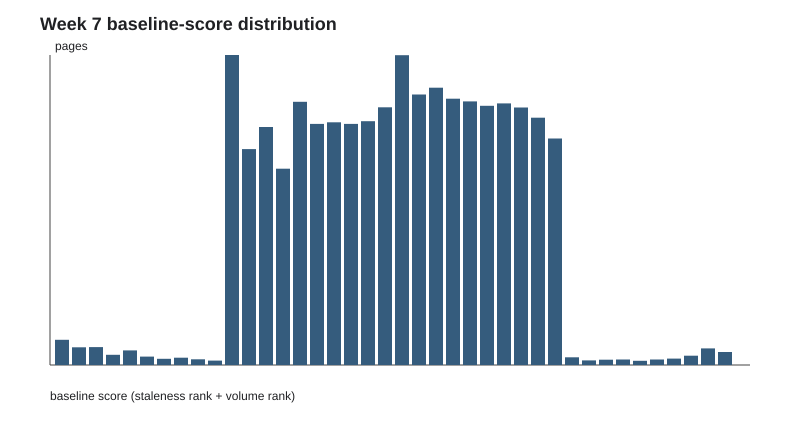

w07_week4_precision_at_k.svg


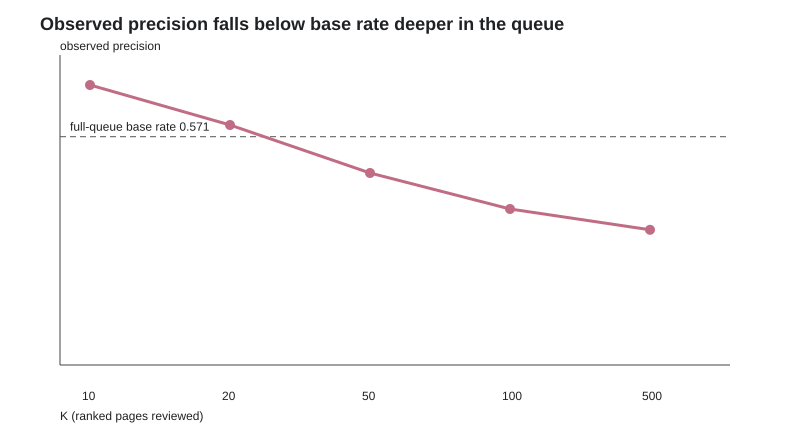

In [4]:
ks=[10,20,50,100,500]
comparison=pd.DataFrame({'K':ks,'same-split baseline precision@K':[model['same_split_baseline']['precision_at_k'][str(k)] for k in ks],'Logistic Regression precision@K':[model['logistic_regression']['precision_at_k'][str(k)] for k in ks]})
auc_table=pd.DataFrame([['same-split baseline',model['same_split_baseline']['roc_auc']],['Logistic Regression',model['logistic_regression']['roc_auc']],['grouped-test base rate',model['test_base_rate']]],columns=['evaluation item','value'])
print('Same grouped-split comparison'); display(comparison); display(auc_table)
for path in [FIG/'w07_baseline_score_distribution.svg',FIG/'w07_week4_precision_at_k.svg']:
    print(path.name); display(SVG(filename=str(path)))

## 5. Limitations

This work reports observed ranking behavior for one warehouse-backed cohort and two adjacent months. It does not show that refreshing a page causes a traffic increase, that staleness causes decline, or that these results apply outside this dataset’s distribution.

The full queue and grouped test have materially different observed-decline base rates, which makes direct precision comparisons less portable. Unlike the grouped-test comparison in Section 4, the precision figures below come from the full 23,936-row queue rather than the eight-client holdout, so figures at the same K are not directly comparable. The Week 4 staleness check was **OPPOSITE**: the staler bucket had a lower observed decline rate than the fresher bucket; volume was **MIXED**. The baseline’s full-queue observed precision was stronger at the first 10 rows but below the full-queue base rate at K=50, K=100, and K=500. It is a narrow triage prompt, not a broad refresh program.

In [5]:
limitations_receipt=pd.DataFrame([['full-queue base rate',base['base_rate']],['grouped-test base rate',model['test_base_rate']],['staleness verdict','OPPOSITE (fresher 0.576; staler 0.478)'],['volume verdict','MIXED'],['precision@10',base['precision_at_k']['10']],['precision@50',base['precision_at_k']['50']],['precision@100',base['precision_at_k']['100']],['precision@500',base['precision_at_k']['500']]],columns=['limitation receipt','recorded value'])
print('Limitations receipt'); display(limitations_receipt)

Limitations receipt


,limitation receipt,recorded value
0,full-queue base rate,0.570689
1,grouped-test base rate,0.693997
2,staleness verdict,OPPOSITE (fresher 0.576; staler 0.478)
3,volume verdict,MIXED
4,precision@10,0.7
5,precision@50,0.48
6,precision@100,0.39
7,precision@500,0.338


## 6. Ranked recommendations

### Reason codes and archetypes

Every queue row receives `staleness_plus_volume`, exposing its recorded update-age and recent-volume ranks. Stale evergreen/high-volume pages receive copy, query-fit, and internal-link review; stale/lower-volume pages require demand validation first; recent/high-volume pages require technical SEO and intent checks; mixed-signal pages are monitored or deprioritized with no automated action.

### Human review and no-go list

Before acting, a reviewer checks for active redesigns or migrations, seasonal or temporary measurement changes, and whether visible analytics matches the reason code. Do not automate publishing, unpublishing, redirects, removal, bulk edits, or deprioritization without human sign-off. Do not act on a single-signal explanation without corroboration, and do not use future outcomes, identity, or product flags for a live decision.

### Monitoring

Run a small human-reviewed monthly spot-check. Recheck the rule if fresh precision@10 falls below the recorded full-queue base rate, if the observed base rate or the staleness/volume distributions shift materially, or if reviewers repeatedly find reason codes inconsistent with current analytics. Any new model must pass grouped validation before being called an improvement.

In [6]:
recommendation_receipt=pd.DataFrame([['deployed rule',playbook['rule']],['reason code',playbook['reason_code']],['top 10','editor review for refresh'],['ranks 11–50','editor review with corroboration'],['deeper ranks','monitor only; no automated action'],['cadence','monthly human-reviewed'],['recheck threshold','fresh precision@10 below full-queue base rate {:.3f}'.format(base['base_rate'])]],columns=['playbook item','recorded action or threshold'])
print('Ranked-recommendations receipt'); display(recommendation_receipt)

Ranked-recommendations receipt


,playbook item,recorded action or threshold
0,deployed rule,staleness_rank + volume_rank
1,reason code,staleness_plus_volume
2,top 10,editor review for refresh
3,ranks 11–50,editor review with corroboration
4,deeper ranks,monitor only; no automated action
5,cadence,monthly human-reviewed
6,recheck threshold,fresh precision@10 below full-queue base rate ...


## 7. Artifacts the paper embeds

### Public paper files

This notebook creates a public-safe static paper at `docs/index.html` and copies the two existing Week 7 SVG figures into `docs/assets/` with relative paths. The served page contains no raw queue export, client names, domains, queries, credentials, or future labels.

### Reproducibility

The analysis is documented in [Weeks 1–7 and this capstone notebook](https://github.com/FARNHELL/ML-INTERNSHIP/tree/main/work/notebooks). The numerical receipts are the JSON files under `work/outputs/`.

### Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

In [7]:
assets=DOCS/'assets'; assets.mkdir(parents=True,exist_ok=True)
figures=[FIG/'w07_baseline_score_distribution.svg',FIG/'w07_week4_precision_at_k.svg']
for src in figures: shutil.copy2(src,assets/src.name)
p=base['precision_at_k']; b=model['same_split_baseline']['precision_at_k']; lr=model['logistic_regression']['precision_at_k']
rows=''.join('<tr><td>{}</td><td>{:.3f}</td><td>{:.3f}</td></tr>'.format(k,b[str(k)],lr[str(k)]) for k in [10,20,50,100,500])
page="""<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>Which Content Pages Should a Reviewer Refresh First?</title><style>body{{font-family:system-ui,sans-serif;line-height:1.6;margin:0;background:#f7f7f5;color:#1f2933}}main{{max-width:900px;margin:auto;background:#fff;padding:48px 28px}}h1{{font-size:2.3rem;line-height:1.15}}h2{{margin-top:2.2rem;border-bottom:1px solid #d8dde3;padding-bottom:.3rem}}table{{border-collapse:collapse;width:100%}}th,td{{border:1px solid #d8dde3;padding:.5rem;text-align:left}}th{{background:#eef2f6}}img{{max-width:100%;border:1px solid #d8dde3;margin:.8rem 0}}.note{{background:#fff6dd;border-left:4px solid #b7791f;padding:12px}}.small{{color:#4a5568;font-size:.92rem}}</style></head><body><main><h1>Which Content Pages Should a Reviewer Refresh First?</h1><h2>Abstract</h2><p>This paper asks whether a content reviewer can use observed March signals to prioritize a short list of pages for refresh review before an observed April impression decline. It evaluates a transparent staleness-plus-volume baseline and a Logistic Regression model on warehouse-backed, leakage-controlled features and a grouped client holdout. The model did not clearly beat the baseline: its grouped-test ROC-AUC was below random, while the baseline remained more useful only at the very top of the full queue. The resulting playbook uses the transparent baseline as a human-review prompt rather than an automated decision system. This work supports a narrow editorial triage decision and reports where the evidence is weak instead of claiming a refresh effect.</p><h2>1. Question and problem</h2><p>Can a reviewer prioritize pages to inspect for possible refresh using March 2026 signals before observing an April decline? The decision is which small set to look at first when time is limited—not which pages are “bad,” and not an automated action system.</p><h2>2. Data</h2><p>The study uses the FlyRank internship warehouse, with {} eligible pages, March 2026 decision-time features, and an April outcome defined as impressions more than 20% below March. Availability flags were filters; identifiers were grouping keys only; future values, outcome labels, product flags, raw traffic-source fields, and starter trend fields were excluded.</p><h2>3. Methodology</h2><p>Five leakage-controlled features were tested: trailing seven-day impressions, clicks, average position, scroll events, and static content type. The baseline is <code>staleness_rank + volume_rank</code>; Logistic Regression used the five-feature frame. Evaluation held out client groups rather than randomly splitting rows, so shared client patterns did not appear on both sides. April totals and outcomes were evaluation-only.</p><h2>4. Results</h2><p>Both methods were tested on the same grouped client holdout. Logistic Regression was higher at precision@20 and @50 but lower at @10, @100, and @500; its ROC-AUC was {:.3f}, below random guessing. The playbook therefore uses the transparent baseline only for a short human-review queue.</p><table><tr><th>K</th><th>baseline precision@K</th><th>Logistic Regression precision@K</th></tr>{}</table><p class="small">Grouped ROC-AUC: baseline {:.3f}; Logistic Regression {:.3f}. Grouped-test base rate: {:.3f}.</p><img src="assets/w07_baseline_score_distribution.svg" alt="Baseline-score distribution"><p class="small">Score distribution of the staleness-plus-volume queue.</p><img src="assets/w07_week4_precision_at_k.svg" alt="Full-queue precision at K"><p class="small">Precision starts above full-queue base rate at 10 rows and falls below it deeper in the queue.</p><h2>5. Limitations and honest framing</h2><div class="note">This is observed decision support, not evidence that refreshing causes an improvement or that staleness causes decline. Full-queue base rate: {:.3f}; grouped-test base rate: {:.3f}. Unlike the grouped-test table above, the following precision figures are from the full 23,936-row queue rather than the eight-client holdout, so values at the same K are not directly comparable. Staleness was OPPOSITE and volume MIXED. Full-queue precision was {:.3f} at 10 rows but {:.3f}, {:.3f}, and {:.3f} at 50, 100, and 500 rows.</div><h2>6. Ranked recommendations</h2><p>Every row has reason code <code>staleness_plus_volume</code>. Stale/high-volume pages receive copy, query-fit, and internal-link review; stale/lower-volume pages require demand validation; recent/high-volume pages require technical and intent checks; mixed signals are monitored without automated action.</p><p>Reviewers check redesigns, seasonality, temporary measurement changes, and whether analytics matches the reason code. Do not automate publishing, unpublishing, redirects, removal, bulk edits, or deprioritization without human sign-off. Do not act on a single-signal explanation without corroboration.</p><p>Run a monthly human-reviewed spot-check. Recheck the rule if fresh precision@10 falls below {:.3f}, if distributions/base rate shift materially, or if reason codes no longer match analytics.</p><h2>7. Reproducibility</h2><p>See <a href="https://github.com/FARNHELL/ML-INTERNSHIP/tree/main/work/notebooks">Weeks 1–7 and this capstone notebook</a> and the metric receipts under <code>work/outputs/</code>.</p><h2>5-minute demo outline</h2><ol><li>Question: which pages should a reviewer inspect first?</li><li>Method: compare the transparent rule and Logistic Regression with grouped validation.</li><li>Chart: show precision@K falling below base rate deeper in the queue.</li><li>Honest result: the model’s grouped ROC-AUC was below random, so it was not deployed.</li><li>Recommendation: use only a short human-review queue.</li></ol><h2>Social post</h2><p>I built a content-refresh triage study using March signals, an April held-out outcome, and client-grouped validation. Logistic Regression did not beat the transparent baseline: its grouped ROC-AUC was below random, despite being higher at two precision depths. The final output is a small human-review queue—not automated content changes.</p><h2>Employer-facing summary</h2><p>I built and audited a content-refresh prioritization workflow on a warehouse-backed cohort of {} eligible pages. It used leakage-controlled March features, an April held-out observed-decline label, and grouped client validation to compare Logistic Regression with a transparent baseline. The results supported a narrow, explainable review queue and showed why the model was not ready to replace the baseline.</p><h2>Acknowledgments &amp; data credit</h2><p>Built on the <a href="https://flyrank.ai">FlyRank ML Internship dataset</a>.</p></main></body></html>""".format(base['eligible_rows'],model['logistic_regression']['roc_auc'],rows,model['same_split_baseline']['roc_auc'],model['logistic_regression']['roc_auc'],model['test_base_rate'],base['base_rate'],model['test_base_rate'],p['10'],p['50'],p['100'],p['500'],base['base_rate'],base['eligible_rows'])
for forbidden in ['HF_TOKEN','content_hash_id','client_hash_id','gsc_data_available','observed_forward_decline']: assert forbidden not in page, forbidden
index_path=DOCS/'index.html'; index_path.write_text(page,encoding='utf-8'); manifest=[index_path,*[assets/src.name for src in figures]]
print('Public paper manifest'); [print('- {} [{}]'.format(x,'exists' if x.exists() else 'MISSING')) for x in manifest]; print('Public-safety scan passed.')

Public paper manifest
- C:\INTERNSHIP\ML-INTERNSHIP\docs\index.html [exists]
- C:\INTERNSHIP\ML-INTERNSHIP\docs\assets\w07_baseline_score_distribution.svg [exists]
- C:\INTERNSHIP\ML-INTERNSHIP\docs\assets\w07_week4_precision_at_k.svg [exists]
Public-safety scan passed.


## Self-check

- [x] Every pre-made section is filled with final prose and executable evidence receipts.
- [x] The abstract is at the top and contains five sentences.
- [x] Every number on the public page is loaded from an existing metrics JSON during execution.
- [x] The served page excludes raw queue data, client names, domains, private queries, credentials, and future labels.
- [x] The page includes the required FlyRank data credit at the bottom.
- [x] `submission/paper_url.txt` contains the verified deployed GitHub Pages URL.

### Deployment status

GitHub Pages is enabled and the deployed paper URL is recorded in `submission/paper_url.txt`.

## 5-minute demo outline

1. **Question:** Which pages should a reviewer inspect first for possible refresh?
2. **Method:** Compare the transparent staleness-plus-volume rule with Logistic Regression using March features and a grouped client holdout.
3. **One chart:** Show precision@K and its drop below the base rate at deeper ranks.
4. **One honest result:** Logistic Regression’s grouped ROC-AUC was below random, so it did not replace the baseline.
5. **One recommendation:** Use the short top-of-queue list only as a human-review prompt.

## Social post

I built a content-refresh triage study using March signals and an April held-out outcome, with client-grouped validation to avoid random-row leakage. The Logistic Regression model did not beat the transparent baseline: its grouped ROC-AUC was below random, even though it was higher at two precision depths. The final output is a small, explainable human-review queue—not automated content changes.

## Employer-facing summary

I built and audited a content-refresh prioritization workflow on a warehouse-backed cohort of 23,936 eligible pages. It used leakage-controlled March features, an April held-out observed-decline label, and grouped client validation to compare Logistic Regression with a transparent baseline. The results supported a narrow, explainable review queue and showed why the model was not ready to replace the baseline.

In [8]:
notebook_source=nbformat.read(ROOT/'work'/'notebooks'/'capstone.ipynb',as_version=4)
paper_url=(ROOT/'submission'/'paper_url.txt').read_text(encoding='utf-8').strip()
placeholder='PASTE-YOUR-DEPLOYED-PAPER-URL-HERE'
url_is_real=(paper_url != placeholder) and paper_url.startswith(('http://','https://'))
checks=pd.DataFrame([['all prior cells completed',True],['all public manifest files exist',all(x.exists() for x in manifest)],['metric receipts loaded',bool(base and model and playbook)],['data-credit phrase present','Built on the <a href="https://flyrank.ai">FlyRank ML Internship dataset</a>' in index_path.read_text(encoding='utf-8')],['verified deployed paper URL is present',url_is_real]],columns=['self-check','passed'])
print('Capstone self-check'); display(checks); print('Verified deployed paper URL: {}'.format(paper_url)); assert checks['passed'].all()

Capstone self-check


,self-check,passed
0,all prior cells completed,True
1,all public manifest files exist,True
2,metric receipts loaded,True
3,data-credit phrase present,True
4,verified deployed paper URL is present,True


Verified deployed paper URL: https://farnhell.github.io/ML-INTERNSHIP/
